In [1]:
import sys
sys.path.append('..')
from VRT import VRT
from MORES import MORES
import numpy as np
from postprocessing import Mueller2sigma0VH
import matplotlib.pyplot as plt

mores = MORES()
mores.init_from_model_file("../model.toml")
vrt = VRT(mores)
vrt.Mue_volume((30, 180, 30, 0))

array([[ 9.24725730e-02,  8.54178007e-16, -8.92548757e-09,
         5.70947689e-11],
       [ 8.54305694e-16,  9.07366293e-02,  8.84167014e-09,
        -9.24409374e-11],
       [-1.78524343e-08,  1.76821856e-08, -9.15604387e-02,
         1.44754032e-03],
       [-9.56422606e-11,  1.66488976e-10, -1.44754032e-03,
        -9.15604387e-02]])

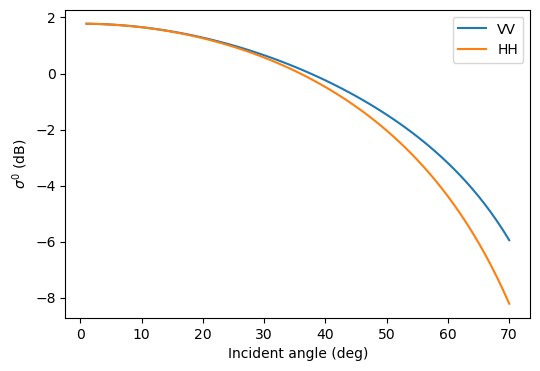

In [2]:
theta_is = np.linspace(1, 70, 70)
Num = len(theta_is)
sigma0_VVs = np.zeros(Num)
sigma0_HHs = np.zeros(Num)
for i in range(Num):
    theta_i = theta_is[i]
    Mue = vrt.Mue_volume((theta_i, 180, theta_i, 0))
    sigma_VV, _, _, sigma_HH = Mueller2sigma0VH(Mue)
    sigma0_VVs[i] = sigma_VV
    sigma0_HHs[i] = sigma_HH

sigma0_VV_dB = 10*np.log10(sigma0_VVs)
sigma0_HH_dB = 10*np.log10(sigma0_HHs)
# sigma0_VV_dB = (sigma0_VVs.real)
# sigma0_HH_dB = (sigma0_HHs.real)
plt.figure(figsize=(6, 4))
plt.plot(theta_is, sigma0_VV_dB, label='VV')
plt.plot(theta_is, sigma0_HH_dB, label='HH')
plt.xlabel('Incident angle (deg)')
plt.ylabel('$\sigma^0$ (dB)')
plt.legend()
plt.show()